In [1]:
import sys
import os
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"
pio.kaleido.scope.mathjax = None

# Set default Plotly template
pio.templates.default = "plotly_dark"

# Add the 'src' directory to the path to import the custom modules
sys.path.append(os.path.abspath(os.path.join('..')))

from src.engine import RiskEngine
from src.data_gen import MarketDataGenerator, PortfolioGenerator

/tmp/ipykernel_37839/4090817885.py:7: DeprecationWarning:


Use of plotly.io.kaleido.scope.mathjax is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.mathjax instead.




Project Setup & Data Generation

First, we initialize the Risk Engine and generate dummy market data (Forward Curves, Volatility) and a sample Trading Portfolio.

Base Date: Jan 1st, 2025

Horizon: 24 Months

In [2]:
# 1. Configuration
BASE_DATE = pd.Timestamp('2025-01-01')
HORIZON_MONTHS = 24

# 2. Generate Market Data (Curves & Discount Factors)
fwd_curves = MarketDataGenerator.generate_forward_curves(BASE_DATE, HORIZON_MONTHS)
discount_curve = MarketDataGenerator.generate_discount_curve(BASE_DATE, HORIZON_MONTHS)

# 3. Generate Risk Matrix (Covariance)
# We map vertices: M1..M12 (First 12 months) + Y2 (Second Year)
vertices = [f'M{i}' for i in range(1, 13)] + ['Y1']
risk_matrix = MarketDataGenerator.generate_risk_matrix(vertices)

# 4. Generate Portfolio (Energy Balance)
portfolio_balance = PortfolioGenerator.generate_energy_balance(BASE_DATE, HORIZON_MONTHS)

# Display sample data
print("--- Sample Portfolio Data ---")
display(portfolio_balance.head())

print("\n--- Forward Curves Snapshot (BRL/MWh) ---")
display(fwd_curves.head())

--- Sample Portfolio Data ---


,Date,Submarket,Source,Portfolio,MW_Avg
0,2025-01-01,NE,Solar,Trading,56.278645
1,2025-01-01,SE,Contract,Trading,-33.154887
2,2025-02-01,NE,Solar,Trading,55.166897
3,2025-02-01,SE,Contract,Trading,-31.454272
4,2025-03-01,NE,Solar,Trading,57.902307



--- Forward Curves Snapshot (BRL/MWh) ---


,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
NE,103.344498,112.360687,120.190890,137.531481,131.905542,131.203516,98.298285,87.973699,70.518668,85.943358,...,146.903501,138.398018,130.750776,122.344509,102.444815,96.980555,82.487458,92.338562,104.803090,123.776594
SE,109.212984,120.862348,131.970457,152.975128,144.828718,148.567448,108.691644,97.103740,77.908509,92.771951,...,160.528035,148.422244,140.658285,133.061939,111.121353,105.942305,87.565136,101.354347,117.331929,138.060039


Market Analysis

Visualizing the Forward Price Curves generated for the Southeast (SE) and South (S) submarkets.

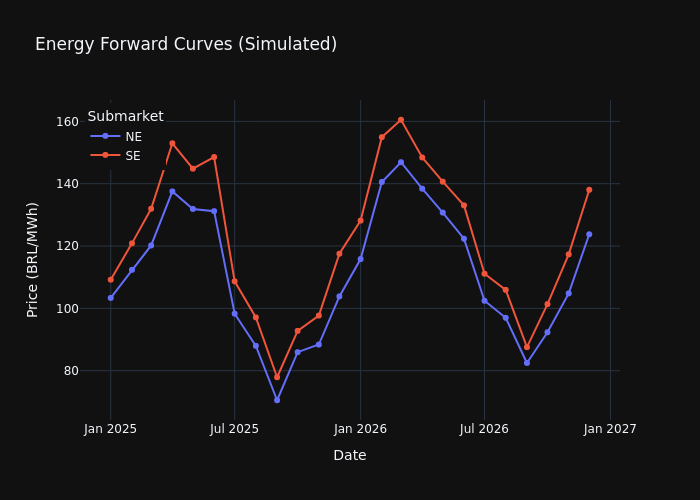

In [3]:
fig = px.line(
    fwd_curves.T,
    title='Energy Forward Curves (Simulated)',
    labels={'index': 'Date', 'value': 'Price (BRL/MWh)', 'variable': 'Submarket'},
    markers=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Price (BRL/MWh)",
    hovermode="x unified", # Mostra o preço de SE e S juntos ao passar o mouse
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)
fig.show()

Mark-to-Market (MtM) Calculation

We calculate the fair value of the portfolio by comparing the contracted positions against the current forward curves, discounting the cash flows to the Base Date.

2026-02-04 03:09:15,592 - src.engine - INFO - Starting MtM calculation...
2026-02-04 03:09:15,602 - src.engine - INFO - MtM calculation finished. Total Value: BRL 31,031,712.12


--- Total Portfolio MtM: BRL 31,031,712.12 ---


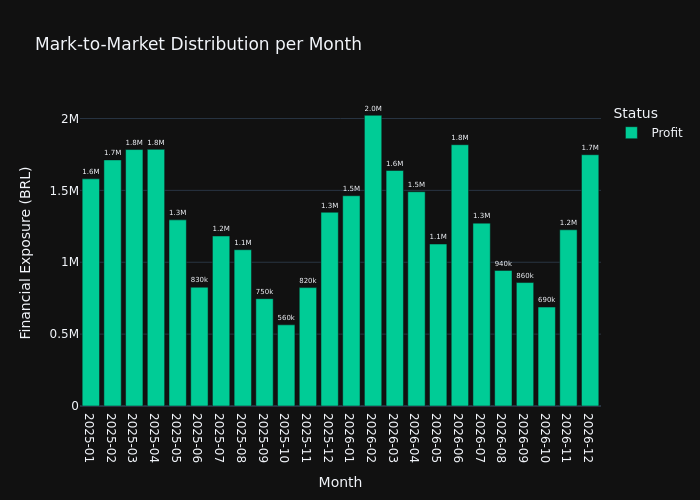

In [4]:
# Initialize Engine
engine = RiskEngine()

# Calculate MtM
mtm_matrix, total_mtm = engine.calculate_mtm(portfolio_balance, fwd_curves, discount_curve)

print(f"--- Total Portfolio MtM: BRL {total_mtm:,.2f} ---")

# Prepare data for Plotly
mtm_per_month = mtm_matrix.sum()
# Convert Series to DataFrame for easier plotting with custom colors
df_mtm = mtm_per_month.to_frame(name='MtM Value')
# Format index for better labels
df_mtm.index = df_mtm.index.strftime('%Y-%m')
# Define color based on profit/loss
df_mtm['Status'] = df_mtm['MtM Value'].apply(lambda x: 'Profit' if x >= 0 else 'Loss')

# Plot Interactive Bar Chart
fig = px.bar(
    df_mtm,
    y='MtM Value',
    color='Status',
    title='Mark-to-Market Distribution per Month',
    color_discrete_map={'Profit': '#00CC96', 'Loss': '#EF553B'}, # Professional green/red hex codes
    text_auto='.2s' # Show Values on bars (k/M suffix)
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Financial Exposure (BRL)",
    xaxis={'type': 'category'} # Ensures dates are treated as labels
)
fig.update_traces(textposition='outside')
fig.show()

Parametric VaR Calculation

Here we estimate the Value at Risk (VaR) with 95% confidence. The engine maps the monthly exposures to the risk vertices (M1, M2... Y1) and applies the Delta-Normal approach.

2026-02-04 03:09:15,799 - src.engine - INFO - Starting Parametric VaR calculation...
2026-02-04 03:09:15,805 - src.engine - INFO - VaR calculated: BRL 3,044,156.76 (Confidence: 95.0%)


--- Parametric VaR (95%): BRL 3,044,156.76 ---


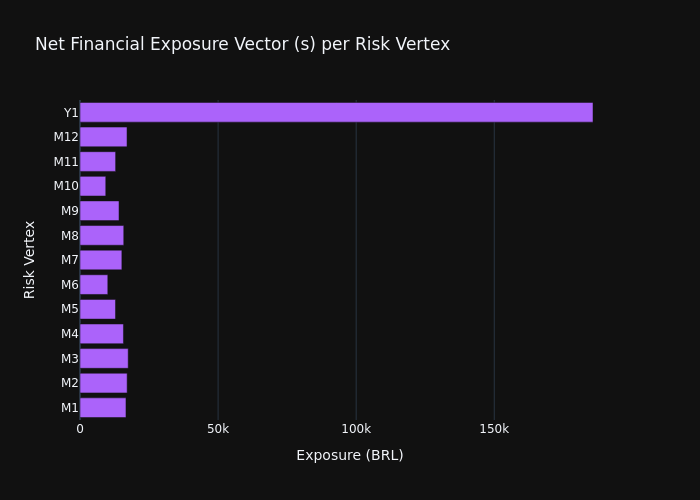

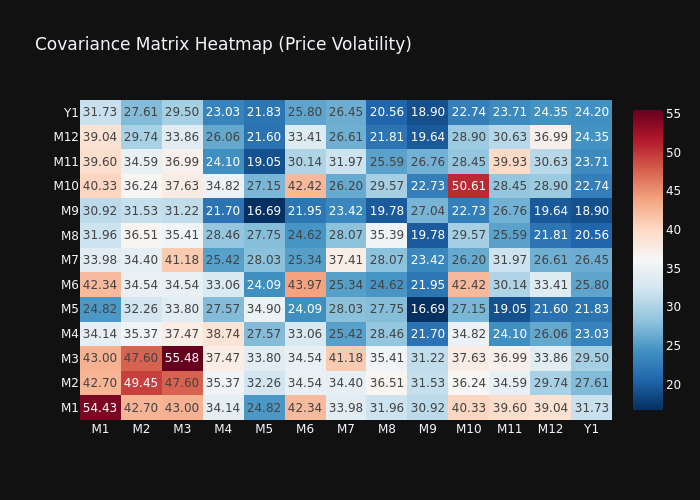

In [5]:
# Calculate VaR
var_value, exposure_financial = engine.calculate_parametric_var(portfolio_balance, risk_matrix, BASE_DATE)

print(f"--- Parametric VaR (95%): BRL {var_value:,.2f} ---")

# --- Chart 1: Financial Exposure Vector (s) ---
fig_exp = px.bar(
    exposure_financial, 
    orientation='h', # Horizontal bars look better for vertex labels
    title='Net Financial Exposure Vector (s) per Risk Vertex',
    labels={'index': 'Risk Vertex', 'value': 'Exposure (BRL)'},
    color_discrete_sequence=['#AB63FA'] # A nice purple color
)
fig_exp.update_layout(showlegend=False)
fig_exp.show()

# --- Chart 2: Risk Matrix Heatmap ---
# Using imshow is the easiest way to plot matrix heatmaps in Plotly
fig_heat = px.imshow(
    risk_matrix,
    text_auto='.2f', # Show correlation values inside cells
    aspect="auto",
    title='Covariance Matrix Heatmap (Price Volatility)',
    color_continuous_scale='RdBu_r', # Red-Blue diverging scale (Red = High Covariance)
    origin='lower' # Standard matrix orientation
)

fig_heat.update_xaxes(side="bottom")
fig_heat.show()